# Geometry-aware HOMO–LUMO gap prediction with SchNet

This notebook evaluates the maintained PyTorch Geometric SchNet implementation. Every model input is derived exclusively from `json_conformer`: atomic numbers, Cartesian coordinates, and batch membership. No quantum-mechanical property is used as an input.

## Notebook contract

**Goal:** evaluate explicit 3D message passing against the best classical baseline.  
**Inputs:** labeled conformers, the exact notebook-02 splits, and classical metrics/features.  
**Outputs:** SchNet checkpoints, `results/schnet_metrics.csv`, molecule comparisons, and diagnostics.  
**Main questions:** Does SchNet improve random or scaffold generalization enough to justify its complexity?


## 1. Setup, reproducibility, and labeled molecules

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))


In [ ]:
# Standard library
import copy
import json

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from rdkit import Chem
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import torch
from torch_geometric.data import Data

# Project
from src.config import (
    CACHE_DIR, CLASSICAL_METRICS, CLASSICAL_RANDOM_PREDICTIONS,
    DATA_PATH, MODEL_DIR, PROJECT_ROOT, RANDOM_SEED, RESULTS_DIR,
    SCHNET_METRICS, SCHNET_RANDOM_PREDICTIONS, SCHNET_SCAFFOLD_PREDICTIONS,
    SPLIT_ARTIFACT, CLASSICAL_FIGURE_DIR,
)
from src.data import (
    labeled_molecules, load_dataset, load_required_csv,
    validate_prediction_alignment, validate_prediction_split,
)
from src.plotting import configure_matplotlib, save_figure
from src.schnet import make_dataloader, predict, train_schnet
from src.utils import seed_everything, select_torch_device


In [ ]:
ROOT = PROJECT_ROOT
FIGURE_DIR = CLASSICAL_FIGURE_DIR
RANDOM_STATE = RANDOM_SEED
for directory in (RESULTS_DIR, FIGURE_DIR, MODEL_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)
configure_matplotlib()
seed_everything(RANDOM_STATE, deterministic_torch=True)
DEVICE = select_torch_device()
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

df = load_dataset(DATA_PATH)
labeled = labeled_molecules(df)
y = labeled["gap"].to_numpy(dtype=np.float32)
print(f"Labeled molecules: {len(labeled):,}; excluded unlabeled rows: {len(df)-len(labeled):,}")


## 2. Molecular graphs

Each graph contains only `z` (atomic number), `pos` (3D coordinates), and `y` for optimization/evaluation. PyG creates the molecule `batch` vector during collation. Scaffolds are computed only to reproduce the split, never as model features.

In [2]:
cache_tag = f"{len(labeled)}_{int(DATA_PATH.stat().st_mtime)}"
graph_cache = CACHE_DIR / f"schnet_graphs_{cache_tag}.pt"

if graph_cache.exists():
    cached = torch.load(graph_cache, map_location="cpu", weights_only=False)
    atomic_numbers = cached["atomic_numbers"]
    positions = cached["positions"]
    scaffolds = cached["scaffolds"]
    print("Loaded deterministic molecular graph cache.")
else:
    atomic_numbers, positions, scaffolds = [], [], []
    for js in labeled["json_conformer"]:
        mol = Chem.JSONToMols(js)[0]
        atomic_numbers.append(torch.tensor(
            [atom.GetAtomicNum() for atom in mol.GetAtoms()], dtype=torch.long
        ))
        positions.append(torch.tensor(
            mol.GetConformer().GetPositions(), dtype=torch.float32
        ))
        mol_2d = Chem.RemoveHs(mol)
        scaffolds.append(Chem.MolToSmiles(
            MurckoScaffold.GetScaffoldForMol(mol_2d), canonical=True
        ))
    torch.save({
        "atomic_numbers": atomic_numbers,
        "positions": positions,
        "scaffolds": scaffolds,
    }, graph_cache)
    print("Created deterministic molecular graph cache.")

scaffolds = np.asarray(scaffolds, dtype=str)
graphs = [
    Data(z=z, pos=pos, y=torch.tensor([target], dtype=torch.float32))
    for z, pos, target in zip(atomic_numbers, positions, y)
]
n_atoms = np.asarray([len(z) for z in atomic_numbers])
print({
    "graphs": len(graphs),
    "atoms_min": int(n_atoms.min()),
    "atoms_median": float(np.median(n_atoms)),
    "atoms_max": int(n_atoms.max()),
    "unique_scaffolds_including_empty": int(np.unique(scaffolds).size),
})

Loaded deterministic molecular graph cache.


{'graphs': 57136, 'atoms_min': 3, 'atoms_median': 18.0, 'atoms_max': 29, 'unique_scaffolds_including_empty': 20646}


## 3. Exact split reproduction from notebook 02

In [ ]:
all_idx = np.arange(len(labeled))
random_train_idx, random_temp_idx = train_test_split(
    all_idx, test_size=0.30, random_state=RANDOM_STATE
)
random_val_idx, random_test_idx = train_test_split(
    random_temp_idx, test_size=0.50, random_state=RANDOM_STATE
)

scaffold_groups = {}
for idx, scaffold in enumerate(scaffolds):
    scaffold_groups.setdefault(scaffold, []).append(idx)
ordered_groups = sorted(
    scaffold_groups.items(), key=lambda item: (-len(item[1]), item[0])
)
train_cutoff = int(0.70 * len(labeled))
validation_cutoff = int(0.85 * len(labeled))
scaffold_train, scaffold_validation, scaffold_test = [], [], []
for _, group_indices in ordered_groups:
    if len(scaffold_train) + len(group_indices) <= train_cutoff:
        scaffold_train.extend(group_indices)
    elif (
        len(scaffold_train) + len(scaffold_validation) + len(group_indices)
        <= validation_cutoff
    ):
        scaffold_validation.extend(group_indices)
    else:
        scaffold_test.extend(group_indices)
scaffold_train_idx = np.asarray(scaffold_train, dtype=int)
scaffold_val_idx = np.asarray(scaffold_validation, dtype=int)
scaffold_test_idx = np.asarray(scaffold_test, dtype=int)


### 3.2 Register and validate split membership


In [ ]:
splits = {
    "random": (random_train_idx, random_val_idx, random_test_idx),
    "scaffold": (scaffold_train_idx, scaffold_val_idx, scaffold_test_idx),
}
split_rows = []
for name, (train_idx, val_idx, test_idx) in splits.items():
    split_rows.append({
        "split": name,
        "train": len(train_idx),
        "validation": len(val_idx),
        "test": len(test_idx),
        "train_pct": 100 * len(train_idx) / len(labeled),
        "validation_pct": 100 * len(val_idx) / len(labeled),
        "test_pct": 100 * len(test_idx) / len(labeled),
        "train_validation_scaffold_overlap": (
            len(set(scaffolds[train_idx]) & set(scaffolds[val_idx]))
            if name == "scaffold" else np.nan
        ),
        "train_test_scaffold_overlap": (
            len(set(scaffolds[train_idx]) & set(scaffolds[test_idx]))
            if name == "scaffold" else np.nan
        ),
    })
display(pd.DataFrame(split_rows).set_index("split"))

## 4. SchNet training utilities

Training minimizes MAE and monitors validation MAE. The best epoch is checkpointed; patience is four epochs. Two compact configurations provide limited tuning of hidden width, interaction blocks, cutoff, learning rate, and batch size.

In [4]:






CONFIGS = [
    {
        "hidden_channels": 32, "num_interactions": 2, "cutoff": 5.0,
        "learning_rate": 1e-3, "batch_size": 128,
        "max_epochs": 25, "patience": 4, "min_delta": 1e-5,
    },
    {
        "hidden_channels": 64, "num_interactions": 3, "cutoff": 6.0,
        "learning_rate": 5e-4, "batch_size": 256,
        "max_epochs": 25, "patience": 4, "min_delta": 1e-5,
    },
]
display(pd.DataFrame(CONFIGS))

,hidden_channels,num_interactions,cutoff,learning_rate,batch_size,max_epochs,patience,min_delta
0,32,2,5.0,0.0010,128,25,4,0.00001
1,64,3,6.0,0.0005,256,25,4,0.00001


## 5. Limited random-split model selection

Both candidates train only on the 70% random training subset. Validation MAE selects the configuration and stopping epoch. Random-test labels are not evaluated here.

In [5]:
candidate_runs = []
for candidate_id, config in enumerate(CONFIGS, start=1):
    checkpoint_path = MODEL_DIR / f"schnet_random_candidate_{candidate_id}.pt"
    run = train_schnet(
        config, graphs, random_train_idx, random_val_idx, checkpoint_path,
        seed=RANDOM_STATE + candidate_id, device=DEVICE,
    )
    run["candidate_id"] = candidate_id
    run["config"] = config
    run["checkpoint_path"] = checkpoint_path
    candidate_runs.append(run)
    print(
        f"Candidate {candidate_id}: best validation MAE={run['best_validation_mae']:.6f} "
        f"at epoch {run['best_epoch']} ({run['training_seconds']:.1f} s)"
    )

candidate_summary = pd.DataFrame([
    {
        "candidate": run["candidate_id"],
        **run["config"],
        "best_epoch": run["best_epoch"],
        "validation_mae": run["best_validation_mae"],
        "training_time_seconds": run["training_seconds"],
        "trainable_parameters": run["parameters"],
    }
    for run in candidate_runs
]).sort_values("validation_mae")
display(candidate_summary)
best_run = min(candidate_runs, key=lambda run: run["best_validation_mae"])
best_config = best_run["config"]
best_random_checkpoint = MODEL_DIR / "schnet_best_random.pt"
torch.save(torch.load(best_run["checkpoint_path"], map_location="cpu", weights_only=False),
           best_random_checkpoint)
print("Selected candidate:", best_run["candidate_id"])

Candidate 1: best validation MAE=0.014243 at epoch 25 (387.4 s)


Candidate 2: best validation MAE=0.014845 at epoch 25 (983.5 s)


,candidate,hidden_channels,num_interactions,cutoff,learning_rate,batch_size,max_epochs,patience,min_delta,best_epoch,validation_mae,training_time_seconds,trainable_parameters
0,1,32,2,5.0,0.0010,128,25,4,0.00001,25,0.014243,387.369580,13793
1,2,64,3,6.0,0.0005,256,25,4,0.00001,25,0.014845,983.508637,63233


Selected candidate: 1


## 6. Random-test evaluation and learning curves

,SchNet random split
validation_mae,0.014243
test_mae,0.014572
test_rmse,0.366911
test_r2,0.019825
training_time_seconds,387.369580
trainable_parameters,13793.000000
best_epoch,25.000000


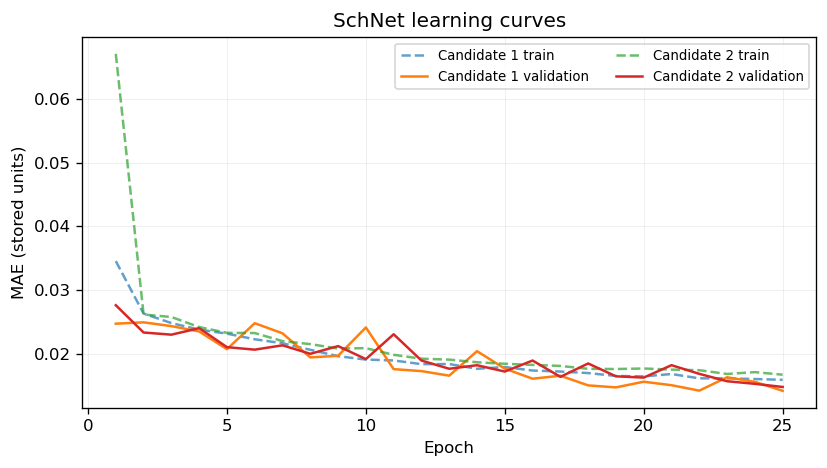

PosixPath('results/figures/schnet_learning_curves.png')

In [6]:
random_test_loader = make_dataloader(graphs, random_test_idx, best_config["batch_size"] * 2, seed=RANDOM_STATE, device=DEVICE)
random_true, random_prediction = predict(best_run["model"], random_test_loader, DEVICE)
random_metrics = {
    "validation_mae": best_run["best_validation_mae"],
    "test_mae": mean_absolute_error(random_true, random_prediction),
    "test_rmse": mean_squared_error(random_true, random_prediction) ** 0.5,
    "test_r2": r2_score(random_true, random_prediction),
    "training_time_seconds": best_run["training_seconds"],
    "trainable_parameters": best_run["parameters"],
    "best_epoch": best_run["best_epoch"],
}
display(pd.Series(random_metrics).to_frame("SchNet random split"))

plt.figure(figsize=(7, 4))
for run in candidate_runs:
    epochs = np.arange(1, len(run["history"]["train_mae"]) + 1)
    plt.plot(epochs, run["history"]["train_mae"], linestyle="--", alpha=0.7,
             label=f"Candidate {run['candidate_id']} train")
    plt.plot(epochs, run["history"]["validation_mae"],
             label=f"Candidate {run['candidate_id']} validation")
plt.xlabel("Epoch")
plt.ylabel("MAE (stored units)")
plt.title("SchNet learning curves")
plt.legend(ncol=2, fontsize=8)
save_figure("schnet_learning_curves", FIGURE_DIR)

random_validation_loader = make_dataloader(
    graphs, random_val_idx, best_config["batch_size"] * 2, seed=RANDOM_STATE, device=DEVICE)
random_validation_true, random_validation_prediction = predict(
    best_run["model"], random_validation_loader, DEVICE)
random_schnet_artifact = pd.concat([
    pd.DataFrame({"mol_id": labeled.iloc[random_val_idx]["mol_id"].to_numpy(), "dataset_index": random_val_idx,
        "split": "random_validation", "target": random_validation_true,
        "prediction": random_validation_prediction}),
    pd.DataFrame({"mol_id": labeled.iloc[random_test_idx]["mol_id"].to_numpy(), "dataset_index": random_test_idx,
        "split": "random_test", "target": random_true, "prediction": random_prediction}),
], ignore_index=True)
random_schnet_artifact["absolute_error"] = (random_schnet_artifact["target"] - random_schnet_artifact["prediction"]).abs()
random_schnet_artifact.to_csv(SCHNET_RANDOM_PREDICTIONS, index=False)
pd.DataFrame({
    f"candidate_{run['candidate_id']}_train_mae": pd.Series(run["history"]["train_mae"])
    for run in candidate_runs
} | {
    f"candidate_{run['candidate_id']}_validation_mae": pd.Series(run["history"]["validation_mae"])
    for run in candidate_runs
}).to_csv(RESULTS_DIR / "schnet_training_history_random.csv", index_label="epoch_zero_based")


## 7. Scaffold robustness

In [7]:
scaffold_checkpoint = MODEL_DIR / "schnet_best_scaffold.pt"
scaffold_run = train_schnet(
    best_config, graphs, scaffold_train_idx, scaffold_val_idx, scaffold_checkpoint,
    seed=RANDOM_STATE + 100, device=DEVICE,
)
scaffold_test_loader = make_dataloader(graphs, scaffold_test_idx, best_config["batch_size"] * 2, seed=RANDOM_STATE, device=DEVICE)
scaffold_true, scaffold_prediction = predict(scaffold_run["model"], scaffold_test_loader, DEVICE)
scaffold_metrics = {
    "validation_mae": scaffold_run["best_validation_mae"],
    "test_mae": mean_absolute_error(scaffold_true, scaffold_prediction),
    "test_rmse": mean_squared_error(scaffold_true, scaffold_prediction) ** 0.5,
    "test_r2": r2_score(scaffold_true, scaffold_prediction),
    "training_time_seconds": scaffold_run["training_seconds"],
    "trainable_parameters": scaffold_run["parameters"],
    "best_epoch": scaffold_run["best_epoch"],
}
display(pd.Series(scaffold_metrics).to_frame("SchNet scaffold split"))

scaffold_validation_loader = make_dataloader(
    graphs, scaffold_val_idx, best_config["batch_size"] * 2, seed=RANDOM_STATE, device=DEVICE)
scaffold_validation_true, scaffold_validation_prediction = predict(
    scaffold_run["model"], scaffold_validation_loader, DEVICE)
scaffold_schnet_artifact = pd.concat([
    pd.DataFrame({"mol_id": labeled.iloc[scaffold_val_idx]["mol_id"].to_numpy(), "dataset_index": scaffold_val_idx,
        "split": "scaffold_validation", "target": scaffold_validation_true,
        "prediction": scaffold_validation_prediction}),
    pd.DataFrame({"mol_id": labeled.iloc[scaffold_test_idx]["mol_id"].to_numpy(), "dataset_index": scaffold_test_idx,
        "split": "scaffold_test", "target": scaffold_true, "prediction": scaffold_prediction}),
], ignore_index=True)
scaffold_schnet_artifact["absolute_error"] = (scaffold_schnet_artifact["target"] - scaffold_schnet_artifact["prediction"]).abs()
scaffold_schnet_artifact.to_csv(SCHNET_SCAFFOLD_PREDICTIONS, index=False)
pd.DataFrame(scaffold_run["history"]).to_csv(
    RESULTS_DIR / "schnet_training_history_scaffold.csv", index_label="epoch_zero_based")


,SchNet scaffold split
validation_mae,0.013148
test_mae,0.019954
test_rmse,0.514755
test_r2,0.012527
training_time_seconds,336.646022
trainable_parameters,13793.000000
best_epoch,19.000000


## 8. Direct comparison with the best classical model

The best random-validation classical family from notebook 02 is compared on both matched test sets. Its saved metrics are used for the table. For molecule-level error differences, its exact random-test predictions are reproduced from the deterministic `json_conformer` feature cache and selected LightGBM parameters.

In [8]:
classical_results = pd.read_csv(RESULTS_DIR / "classical_baselines.csv")
best_classical_random = (
    classical_results[classical_results["split_strategy"] == "random"]
    .sort_values("validation_mae")
    .iloc[0]
)
classical_family = best_classical_random["model"]
classical_scaffold = classical_results[
    (classical_results["split_strategy"] == "scaffold")
    & (classical_results["model"] == classical_family)
].iloc[0]

comparison = pd.DataFrame([
    {
        "split": "random", "model": "SchNet",
        "validation_mae": random_metrics["validation_mae"],
        "test_mae": random_metrics["test_mae"],
        "test_rmse": random_metrics["test_rmse"],
        "test_r2": random_metrics["test_r2"],
        "training_time_seconds": random_metrics["training_time_seconds"],
        "trainable_parameters": random_metrics["trainable_parameters"],
    },
    {
        "split": "random", "model": classical_family,
        "validation_mae": best_classical_random["validation_mae"],
        "test_mae": best_classical_random["test_mae"],
        "test_rmse": best_classical_random["test_rmse"],
        "test_r2": best_classical_random["test_r2"],
        "training_time_seconds": best_classical_random["training_time_seconds"],
        "trainable_parameters": np.nan,
    },
    {
        "split": "scaffold", "model": "SchNet",
        "validation_mae": scaffold_metrics["validation_mae"],
        "test_mae": scaffold_metrics["test_mae"],
        "test_rmse": scaffold_metrics["test_rmse"],
        "test_r2": scaffold_metrics["test_r2"],
        "training_time_seconds": scaffold_metrics["training_time_seconds"],
        "trainable_parameters": scaffold_metrics["trainable_parameters"],
    },
    {
        "split": "scaffold", "model": classical_family,
        "validation_mae": classical_scaffold["validation_mae"],
        "test_mae": classical_scaffold["test_mae"],
        "test_rmse": classical_scaffold["test_rmse"],
        "test_r2": classical_scaffold["test_r2"],
        "training_time_seconds": classical_scaffold["training_time_seconds"],
        "trainable_parameters": np.nan,
    },
])
comparison.to_csv(RESULTS_DIR / "schnet_metrics.csv", index=False)
display(comparison)

,split,model,validation_mae,test_mae,test_rmse,test_r2,training_time_seconds,trainable_parameters
0,random,SchNet,0.014243,0.014572,0.366911,0.019825,387.369580,13793.0
1,random,Morgan + RDKit 2D + simple 3D + LightGBM,0.013886,0.014261,0.367294,0.017775,4.177983,NaN
2,scaffold,SchNet,0.013148,0.019954,0.514755,0.012527,336.646022,13793.0
3,scaffold,Morgan + RDKit 2D + simple 3D + LightGBM,0.014583,0.021821,0.515300,0.010435,6.963754,NaN


## 9. SchNet diagnostics

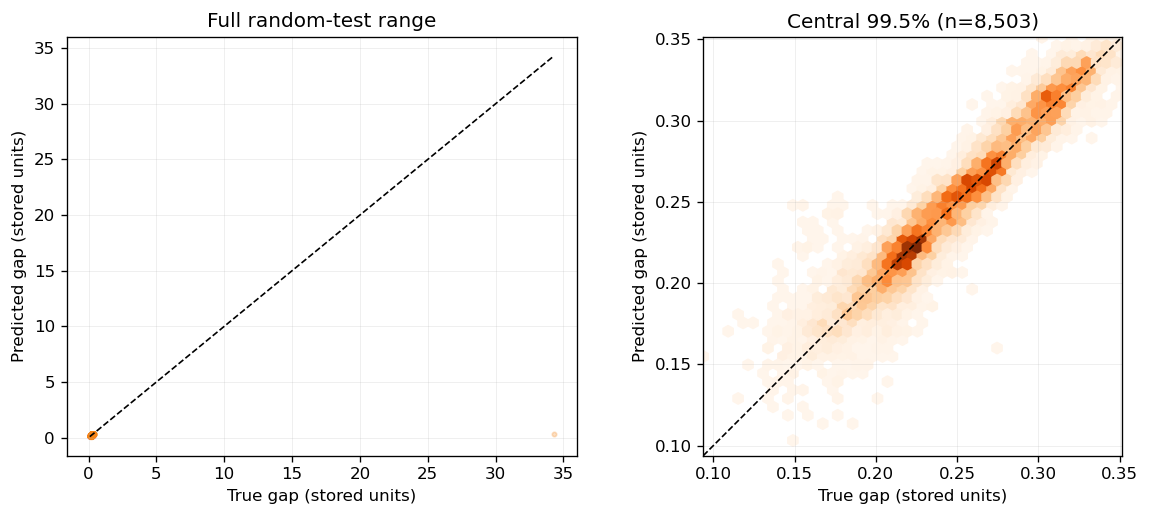

The left panel retains all 8,571 samples. The right panel clips only the display at the reproducible 99.5th-percentile limit (0.3514); all metrics include the tail.

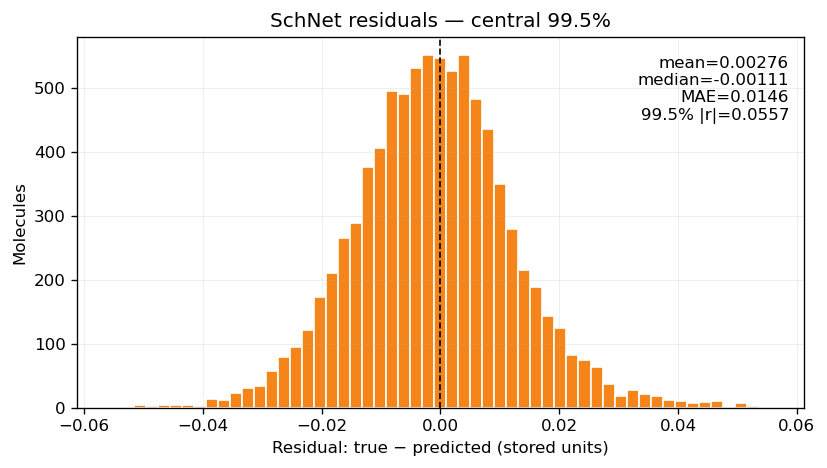

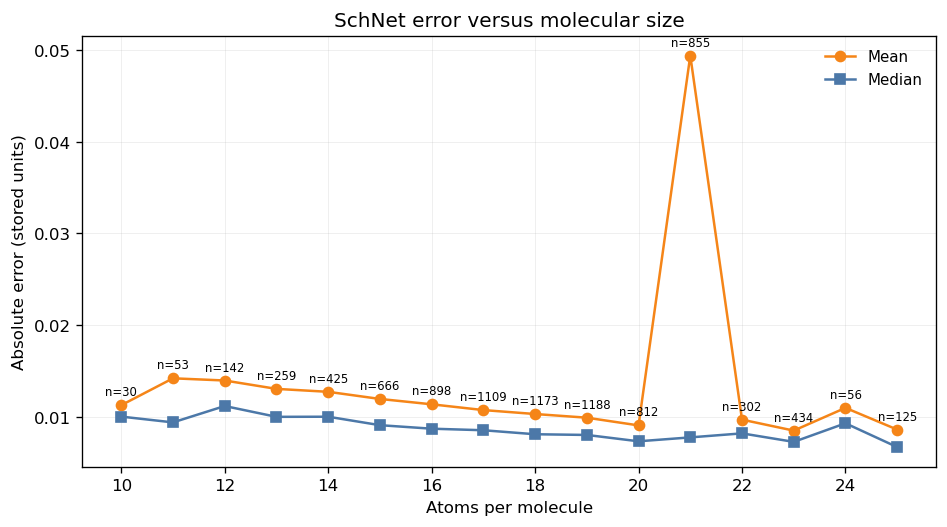

Residual and size visual limits do not affect evaluation. Exact atom-count groups with fewer than 20 test molecules are omitted from the size trend only.

In [9]:
central_limit = np.quantile(np.r_[random_true, random_prediction], .995)
central_mask = (random_true <= central_limit) & (random_prediction <= central_limit)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
full_limits = [min(random_true.min(), random_prediction.min()), max(random_true.max(), random_prediction.max())]
axes[0].scatter(random_true, random_prediction, s=7, alpha=.25, color="#F58518", rasterized=True)
axes[0].plot(full_limits, full_limits, "--", color="black", linewidth=1)
axes[0].set(xlabel="True gap (stored units)", ylabel="Predicted gap (stored units)", title="Full random-test range")
zoom_limits = [min(random_true[central_mask].min(), random_prediction[central_mask].min()), central_limit]
axes[1].hexbin(random_true[central_mask], random_prediction[central_mask], gridsize=42, mincnt=1, cmap="Oranges")
axes[1].plot(zoom_limits, zoom_limits, "--", color="black", linewidth=1)
axes[1].set(xlim=zoom_limits, ylim=zoom_limits, aspect="equal",
            xlabel="True gap (stored units)", ylabel="Predicted gap (stored units)",
            title=f"Central 99.5% (n={central_mask.sum():,})")
save_figure("schnet_predicted_vs_true", FIGURE_DIR)
display(Markdown(
    f"The left panel retains all {len(random_true):,} samples. The right panel clips only the display "
    f"at the reproducible 99.5th-percentile limit ({central_limit:.4g}); all metrics include the tail."
))

random_residual = random_true - random_prediction
residual_limit = np.quantile(np.abs(random_residual), .995)
plt.figure(figsize=(7, 4))
plt.hist(random_residual[np.abs(random_residual) <= residual_limit], bins=55, color="#F58518", edgecolor="white")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Residual: true − predicted (stored units)")
plt.ylabel("Molecules")
plt.title("SchNet residuals — central 99.5%")
plt.text(.98, .95, f"mean={random_residual.mean():.3g}\nmedian={np.median(random_residual):.3g}\nMAE={np.abs(random_residual).mean():.3g}\n99.5% |r|={residual_limit:.3g}",
         transform=plt.gca().transAxes, ha="right", va="top")
save_figure("schnet_residual_histogram", FIGURE_DIR)

random_atoms = n_atoms[random_test_idx]
size_error = (
    pd.DataFrame({"n_atoms": random_atoms.astype(int), "absolute_error": np.abs(random_residual)})
    .groupby("n_atoms")["absolute_error"].agg(["mean", "median", "count"]).reset_index()
)
size_plot = size_error[size_error["count"] >= 20]
plt.figure(figsize=(8, 4.5))
plt.plot(size_plot["n_atoms"], size_plot["mean"], marker="o", color="#F58518", label="Mean")
plt.plot(size_plot["n_atoms"], size_plot["median"], marker="s", color="#4C78A8", label="Median")
for row in size_plot.itertuples():
    plt.annotate(f"n={row.count}", (row.n_atoms, row.mean), xytext=(0, 6),
                 textcoords="offset points", ha="center", fontsize=7)
plt.xlabel("Atoms per molecule")
plt.ylabel("Absolute error (stored units)")
plt.title("SchNet error versus molecular size")
plt.legend(frameon=False)
save_figure("schnet_error_vs_size", FIGURE_DIR)
display(Markdown("Residual and size visual limits do not affect evaluation. Exact atom-count groups with fewer than 20 test molecules are omitted from the size trend only."))


## 10. Molecules improved or worsened relative to LightGBM

In [10]:
classical_artifact = load_required_csv(
    CLASSICAL_RANDOM_PREDICTIONS, "notebooks/02_classical_baselines.ipynb")
classical_test = classical_artifact.query("split == 'random_test'").reset_index(drop=True)
validate_prediction_alignment(classical_test, labeled)
validate_prediction_split(classical_test, random_test_idx, split="random_test")
np.testing.assert_allclose(classical_test["target"], random_true, rtol=0, atol=0)
classical_prediction = classical_test["prediction"].to_numpy()

comparison_by_molecule = pd.DataFrame({
    "mol_id": labeled.iloc[random_test_idx]["mol_id"].to_numpy(),
    "true_gap": random_true,
    "schnet_prediction": random_prediction,
    "lightgbm_prediction": classical_prediction,
    "schnet_absolute_error": np.abs(random_true - random_prediction),
    "lightgbm_absolute_error": np.abs(random_true - classical_prediction),
    "n_atoms": n_atoms[random_test_idx],
    "scaffold": scaffolds[random_test_idx],
})
comparison_by_molecule["schnet_error_improvement"] = (
    comparison_by_molecule["lightgbm_absolute_error"]
    - comparison_by_molecule["schnet_absolute_error"])
comparison_by_molecule["structure_group"] = np.where(
    comparison_by_molecule["scaffold"].eq(""), "acyclic", "cyclic")
comparison_by_molecule.to_csv(
    RESULTS_DIR / "schnet_vs_lightgbm_molecule_analysis.csv", index=False)

display(Markdown("**Largest SchNet improvements**"))
display(comparison_by_molecule.nlargest(15, "schnet_error_improvement"))
display(Markdown("**Largest SchNet degradations**"))
display(comparison_by_molecule.nsmallest(15, "schnet_error_improvement"))
group_analysis = (comparison_by_molecule
    .groupby(["structure_group", "n_atoms"])["schnet_error_improvement"]
    .agg(["mean", "median", "count"]).query("count >= 20").sort_values("mean", ascending=False))
display(Markdown("**Error change by broad molecular group (positive favors SchNet)**"))
display(group_analysis)


**Largest SchNet improvements**

,mol_id,true_gap,schnet_prediction,lightgbm_prediction,schnet_absolute_error,lightgbm_absolute_error,n_atoms,scaffold,schnet_error_improvement,structure_group
1460,115101,0.1132,0.128375,0.211243,0.015175,0.098043,17,c1ccoc1,0.082868,cyclic
6738,3852,0.2140,0.219465,0.299801,0.005465,0.085801,19,C1C[C@H2]1,0.080336,cyclic
884,23280,0.1738,0.248554,0.324288,0.074754,0.150488,18,C1[C@H2][C@@H]2[C@@H]3[C@H2][C@H]1[C@H]23,0.075735,cyclic
5220,3971,0.2021,0.225190,0.300485,0.023090,0.098385,20,C1[C@H2][C@@H]2[C@@H2][N@@H+]3[C@H2][C@H]1[C@H]23,0.075295,cyclic
5507,69005,0.1694,0.240623,0.312986,0.071223,0.143586,19,C1[C@H2][C@H]2C3[C@H]2[C@H2][C@H]13,0.072364,cyclic
3408,52402,0.1706,0.168558,0.237981,0.002042,0.067381,15,C1N=NNCN1,0.065339,cyclic
3961,25845,0.1675,0.172182,0.234492,0.004682,0.066992,14,c1nnnnc1[C@H]1[C@@H2]N1,0.062310,cyclic
1076,591,0.1852,0.212080,0.272285,0.026880,0.087085,16,[C@@H2]1[C@@H2][C@H]2NNN3[C@H2][C@@H]1[C@@H]23,0.060205,cyclic
3353,96990,0.1512,0.145427,0.212455,0.005773,0.061255,11,c1cc2c([nH]1)=NONN=2,0.055482,cyclic
3746,7498,0.1616,0.182892,0.237419,0.021292,0.075819,17,[C+]1[CH+]N=CO[CH+]1,0.054527,cyclic


**Largest SchNet degradations**

,mol_id,true_gap,schnet_prediction,lightgbm_prediction,schnet_absolute_error,lightgbm_absolute_error,n_atoms,scaffold,schnet_error_improvement,structure_group
2622,64010,0.2770,0.160658,0.272865,0.116342,0.004135,4,,-0.112207,acyclic
5337,40605,0.2098,0.138999,0.214844,0.070801,0.005044,17,,-0.065757,acyclic
1352,53581,0.2010,0.130902,0.205508,0.070098,0.004508,17,,-0.065590,acyclic
8057,68972,0.1843,0.112513,0.197528,0.071787,0.013228,7,,-0.058560,acyclic
4600,108972,0.3056,0.364461,0.312309,0.058861,0.006709,19,[C@@H2]1[C@@H]2[C@@H]3[C@H]1[C@H]2[C@H]1[C@@H2...,-0.052152,cyclic
800,108702,0.2193,0.166349,0.218470,0.052951,0.000830,19,C1[C@@H2]C[C@H2][C@@H2]1,-0.052121,cyclic
592,107420,0.2767,0.359114,0.309449,0.082414,0.032749,16,[C@@H2]1[C@@H]2O[C@H]1[C@H]1[C@H2][C@@H]2O1,-0.049665,cyclic
7530,86627,0.2122,0.156261,0.205102,0.055939,0.007098,13,C1[C@@H2]N1,-0.048841,cyclic
4205,55803,0.2276,0.177708,0.226417,0.049892,0.001183,11,n1nn[nH]n1,-0.048709,cyclic
7844,111462,0.2235,0.170283,0.217680,0.053217,0.005820,19,,-0.047397,acyclic


**Error change by broad molecular group (positive favors SchNet)**

mean    median  count
structure_group n_atoms                           
cyclic          10       0.006613  0.005248     25
                13       0.003533  0.002020    237
acyclic         14       0.003003  0.001234     41
cyclic          11       0.002506  0.002369     50
                12       0.001717  0.000618    121
                24       0.001298  0.000211     39
                15       0.001242  0.000319    603
                16       0.000943 -0.000172    809
                14       0.000858  0.000059    384
acyclic         16       0.000814 -0.000468     89
cyclic          25       0.000335 -0.000899     97
acyclic         20      -0.000125 -0.000524     82
cyclic          18      -0.000194 -0.000457   1061
                23      -0.000373 -0.000461    378
                17      -0.000389 -0.000729   1017
acyclic         25      -0.000411  0.002025     28
cyclic          20      -0.000479 -0.000504    730
                22      -0.000907 -0.001245    247
acyclic         18      -0.000978 -0.001091    112
                15      -0.001199  0.000113     63
cyclic          19      -0.001447 -0.001052   1066
acyclic         17      -0.001462 -0.000444     92
                19      -0.001718 -0.001715    122
cyclic          21      -0.001752 -0.001608    777
acyclic         22      -0.001897 -0.001676     55
                21      -0.004614 -0.003037     78
                13      -0.005622 -0.003074     22
                23      -0.005790 -0.005843     56
                12      -0.010171 -0.008533     21

## 11. Discussion

In [11]:
random_delta = best_classical_random["test_mae"] - random_metrics["test_mae"]
scaffold_delta = classical_scaffold["test_mae"] - scaffold_metrics["test_mae"]
better_split = "random" if random_delta > scaffold_delta else "scaffold"
benefit_groups = group_analysis.head(3).index.tolist()
worse_groups = group_analysis.tail(3).index.tolist()
complexity_justified = random_delta > 0 or scaffold_delta > 0

display(Markdown(f'''
### SchNet conclusions

1. **Does explicit 3D message passing improve over handcrafted descriptors?** Random-test MAE changes by {random_delta:+.5f} in SchNet's favor relative to `{classical_family}`; scaffold-test MAE changes by {scaffold_delta:+.5f}. Positive values mean SchNet is better.
2. **Where is the improvement larger?** The larger MAE gain is on the **{better_split} split**. This distinction matters because scaffold evaluation probes transfer to unseen cores.
3. **Which groups benefit?** The strongest broad groups are `{benefit_groups}`; the least-favored are `{worse_groups}`. The detailed per-molecule CSV should be used for chemical inspection rather than inferring causality from these coarse groups.
4. **Is the complexity justified?** {"Yes, as a follow-up model: at least one matched test split improves, although runtime and parameter count must be weighed against the compact LightGBM baseline." if complexity_justified else "Not from these runs: SchNet adds training complexity without improving either matched test MAE. Further architecture scaling is not justified until target provenance and outliers are resolved."}

SchNet uses {best_run["parameters"]:,} trainable parameters and required {best_run["training_seconds"]:.1f} seconds for the selected random-split run on `{DEVICE}`. The model never receives IDs, scaffolds, `gap`, orbital energies, or auxiliary quantum targets as input.
'''))


### SchNet conclusions

1. **Does explicit 3D message passing improve over handcrafted descriptors?** Random-test MAE changes by -0.00031 in SchNet's favor relative to `Morgan + RDKit 2D + simple 3D + LightGBM`; scaffold-test MAE changes by +0.00187. Positive values mean SchNet is better.
2. **Where is the improvement larger?** The larger MAE gain is on the **scaffold split**. This distinction matters because scaffold evaluation probes transfer to unseen cores.
3. **Which groups benefit?** The strongest broad groups are `[('cyclic', 10), ('cyclic', 13), ('acyclic', 14)]`; the least-favored are `[('acyclic', 13), ('acyclic', 23), ('acyclic', 12)]`. The detailed per-molecule CSV should be used for chemical inspection rather than inferring causality from these coarse groups.
4. **Is the complexity justified?** Yes, as a follow-up model: at least one matched test split improves, although runtime and parameter count must be weighed against the compact LightGBM baseline.

SchNet uses 13,793 trainable parameters and required 387.4 seconds for the selected random-split run on `cpu`. The model never receives IDs, scaffolds, `gap`, orbital energies, or auxiliary quantum targets as input.


## Saved artifacts and interpretation

The notebook's scientific findings and conclusions are stated in the preceding sections. Its declared outputs are saved at the paths listed in the **Notebook contract** above. Implementation details shared across experiments live in `src/`; experiment choices and their interpretation remain visible here.
